## Learning the CVA by Neural Net Regression

The CVA at a pricing date $t_i$ is a conditional expectation given the state $\mathcal{X}_{t_i} = (Z_{t_i}, X_{t_i})$ (market risk factors + default indicator): $\mathrm{CVA}_{t_i} = \mathbb{E}[\xi_i \mid \mathcal{X}_{t_i}] =: u_i(\mathcal{X}_{t_i})$, where $\xi_i$ is the pathwise discounted default-loss cash flow accumulated over $[t_i, T]$, whose explicit form depends on the indicator / intensity formulation was introduced in the notebook `1_nested_cva_estimator.ipynb`. We recall both forms here as they directly define the labels fed to the network.

The indicator-based label is $\xi_i^{\,\mathrm{ind}} = \sum_{l=i}^{n-1} \beta_{t_i}^{-1}\,\beta_{t_{l+1}}\,(\mathrm{MtM}_{t_{l+1}})^+\,\mathbf{1}_{\{t_l < \tau \le t_{l+1}\}}$, while the intensity-based label (explicit left-Euler scheme) is given by $\xi_i^{\,\mathrm{int}} = \sum_{l=i}^{n-1} \beta_{t_i}^{-1}\,\beta_{t_l}\,(\mathrm{MtM}_{t_l})^+\,\gamma_{t_l}\,\exp(-\sum_{k=i}^{l-1}\gamma_{t_k})\,\mathbf{1}_{\{t_i < \tau\}}$.

Rather than a NMC, we exploit the $L^2$-projection characterization of the conditional expectation presented in the course: $u_i(\cdot) \in \arg\min_{h \in L^2(\sigma(\mathcal{X}_{t_i}))} \mathbb{E}[(\xi_i - h(\mathcal{X}_{t_i}))^2]$ which reformulates the CVA as a regression problem. Restricting the hypothesis class to a parametric family $\{h_\theta,\ \theta \in \Theta\}$ of neural nets and replacing the population expectation by an empirical mean over $K$ simulated paths $\{\mathcal{X}_{t_i}^{(k)}, \xi_i^{(k)}\}_{k=1}^K$ yields the trained estimator $\hat\theta_i \in \arg\min_{\theta \in \Theta}\;\frac{1}{K}\sum_{k=1}^{K}(\xi_i^{(k)} - h_\theta(\mathcal{X}_{t_i}^{(k)}))^2$, and we set $\hat u_i := h_{\hat\theta_i}$.

We approximate each $u_i = u_i(\mathcal{X}_{t_i})$ by a feedforward neural net $h_{\theta_i}$, a MLP with ReLU activations (given the input dimensionality $d = 2$), a softplus output activation on the output layer only to enforce positive CVA estimates, and a Kaiming initialization specifically derived for ReLU networks [[13]](#he) and zero biases. Training also includes early stopping on a held-out validation split and rollback to the best checkpoint, with Adam as optimizer. Moreover, instead of training the networks independently, we exploit sequential/backward training (presented in the course as a form of transfer learning). We go backward in time over the pricing grid, initializing the network at time $t_i$ with the optimized parameters obtained at $t_{i+1}$ [[9]](#gpw). The NN framework is implemented in `nn_regressor.py`.

In [1]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from simulation.simulation import (
    simulate_outer_market_paths,
    compute_fixing_window_size,
    simulate_nested_cva,
)
from products.irs.gpu import calibrate_swap_rate_at_par
from cva_nn_estimator import compute_cva_labels, LearnedCVA
from nn_regressor import Regressor
from utils import plot_cva_profile
from utils import plot_cva_profile, plot_cva_density, plot_cva_qq
import warnings
import warnings
warnings.filterwarnings("ignore")

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### I. Setup and data training

#### 1.1 Market model and portfolio

We reuse the setup of the NMC notebook (same time grid, risk factors, and IRS book) to allow a direct upcoming comparison bewteen methods

In [2]:
# keeping same params and setup as NMC for direct comparison
# time discretization grid
dT = 0.1
num_substeps = 5
dt = dT / num_substeps
T_horizon = 10.0
num_steps_total = round(T_horizon / dT)

# Risk factors parameters 
# Vasicek short rate (a, b, sigma)
# CIR default intensity (k, theta, xi)
a, b, sigma = 0.3, 0.03, 0.01
k, theta, xi = 0.5, 0.015, 0.01
rho = 0.0
diff_params = (a, b, sigma, k, theta, xi)
r_0, gamma_0 = 0.01, 0.015

In [3]:
# swaps ptf
np.random.seed(0)

num_irs = 500
reset_freq = 0.5

# bank ptf direction bias
prop_pay_fixed = 0.75  # asset heavy
notional = 10000. * (np.random.choice((-1, 1), num_irs, p=(1 - prop_pay_fixed, prop_pay_fixed)) * np.random.choice(range(1, 11), num_irs))

at_par = False   # if true the mtm=0 at t_0 else fixed swap_rate 

irs = []
for i in range(num_irs):
    trade = {
        'first_reset': reset_freq,
        'reset_freq':  reset_freq,
        'num_resets':  int(np.random.randint(6, 21)),
        'notional':    float(notional[i]),
        'swap_rate':   float(np.random.uniform(0.005, 0.05))  # (course case study), random ITM/OTM
    }
    if at_par:
        trade['swap_rate'] = float(
            calibrate_swap_rate_at_par(trade, r_0, a, b, sigma))
    irs.append(trade)

fixing_window_size = compute_fixing_window_size(irs, dt, dT)
max_maturity = max(s['num_resets'] for s in irs) * reset_freq

print(f"portfolio: {num_irs} interest rate swaps")
print(f"  - {prop_pay_fixed:.0%} pay fixed, {1-prop_pay_fixed:.0%} receive fixed")
print(f"  - priced at par: {at_par}")
print(f"  - max maturity: {max_maturity:.1f}y")

portfolio: 500 interest rate swaps
  - 75% pay fixed, 25% receive fixed
  - priced at par: False
  - max maturity: 10.0y


#### 1.2 Outer paths, features and labels

We draw $K$ outer paths and extract at each pricing date $t_i$ the state 
$\mathcal{X}_{t_i}^{(k)} = (Z_{t_i}^{(k)}, X_{t_i}^{(k)})$ as features. 
On the same paths we compute pathwise labels for both formualtions:
$$
\xi_i^{\mathrm{ind},(k)} = \sum_{l=i}^{n-1} \beta_{t_i}^{-1}\,\beta_{t_{l+1}}^{(k)}\,
(\mathrm{MtM}_{t_{l+1}}^{(k)})^+\,\mathbf{1}_{\{t_l < \tau^{(k)} \le t_{l+1}\}},
$$
$$
\xi_i^{\mathrm{int},(k)} = \sum_{l=i}^{n-1} \beta_{t_i}^{-1}\,\beta_{t_l}^{(k)}\,
(\mathrm{MtM}_{t_l}^{(k)})^+\,\gamma_{t_l}^{(k)}\,
\exp\!\Big(-\sum_{j=i}^{l-1}\gamma_{t_j}^{(k)}\Big)\,
\mathbf{1}_{\{t_i < \tau^{(k)}\}}.
$$
Both labels are computed on the same outer sample so that any difference observed between the two formulations reflects the formulations themselves and not Monte Carlo noise.

In the following, we denote by features the state $\mathcal{X}_{t_i}^{(k)} = (Z_{t_i}^{(k)}, X_{t_i}^{(k)})$ extracted at each pricing date, by label the pathwise $\xi_i^{(k)}$ (in either the indicator or intensity formulation), and by outer paths the $K$ independent trajectories of the risk factors used to generate the training sample.

In [4]:
num_outer_paths = 2**15          
rng = np.random.default_rng(42)
X, default_step, rate_integral_path, gamma_integral_path = simulate_outer_market_paths(
    num_outer_paths=num_outer_paths,
    num_steps_total=num_steps_total,
    num_substeps=num_substeps,
    dt=dt,
    fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0,
    diff_params=diff_params,
    rho=rho, rng=rng,
)

In [5]:
# features_by_t 
input_dim = 3
features_by_t = np.zeros((num_steps_total + 1, num_outer_paths, input_dim), dtype=np.float32)
for step in range(num_steps_total + 1):
    idx = (fixing_window_size - 1) if step == 0 else (fixing_window_size + step - 1)
    features_by_t[step, :, 0] = X[idx, 0, :]  # r_t
    features_by_t[step, :, 1] = X[idx, 1, :]  # gamma_t
    features_by_t[step, :, 2] = ((default_step != -1) & (default_step <= step)).astype(np.float32) 

In [6]:
# computing CVA labels
t0 = time.time()
labels_int = compute_cva_labels(
    X, rate_integral_path, gamma_integral_path, default_step,
    irs, diff_params, dt, dT,
    fixing_window_size, num_substeps,
    num_steps_total, num_outer_paths,
    formulation='intensity',
)
#labels_ind = compute_cva_labels(
#    X, rate_integral_path, gamma_integral_path, default_step,
#    irs, diff_params, dt, dT,
#    fixing_window_size, num_substeps,
#    num_steps_total, num_outer_paths,
#    formulation='indicator',
#)
print(f"labels computed in {time.time()-t0:.2f}s")

labels computed in 4.00s


#### II. Learning the CVA

The architecture primarily selected in the notebook `nn_architecture.ipynb` is firstly retained throughout this section.
We now focus on learning the CVA and analyzing the resulting CVA profiles. We restrict outputs to the intensity-based formulation. The indicator-based formulation was also trained but exhibited very noisy learned profiles. As discussed in the course, this could be addressed via hierarchical (over-)simulation of defaults [[2]](#acs).
The indicator-based training code is kept in the notebook (commented out below) and can be re-enabled if needed.

In [7]:
# NN training setup for the intensity-based/indicator-based CVA formulations
nn_cva_kwargs = dict(
    num_steps_total=num_steps_total, input_dim=input_dim,
    hidden_units=16, num_hidden_layers=3,
    lr=1e-3, num_epochs=150, batch_size=256,
    val_frac=0.1, early_stop=True, patience=15,
    device='cuda', seed=0, verbose=True,
)

The indicator-based formulation can also be trained in order to vizualize its (noisy) learning behaviour relative to the the intensity-based formulation.

In [9]:
# intensity
learner_int = LearnedCVA(**nn_cva_kwargs)
learner_int.fit(features_by_t, labels_int, formulation='intensity')
cva_int = learner_int.predict(features_by_t)

# indicator
#learner_ind = LearnedCVA(**nn_cva_kwargs)
#learner_ind.fit(features_by_t, labels_ind, formulation='indicator')
#cva_ind = learner_ind.predict(features_by_t)

Run backward NN training (CVA, intensity): 100%|██████████| 101/101 [11:24<00:00,  6.78s/it, mode=const, t=0]


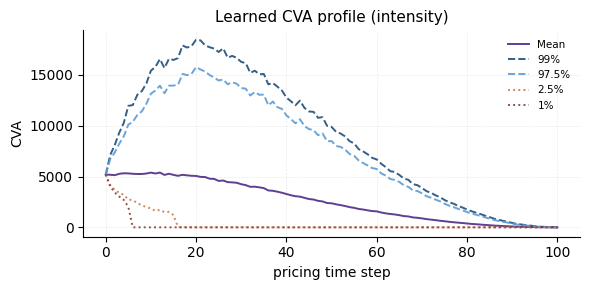

In [10]:
# Plot learned CVA profile
fig, ax = plt.subplots(1, 1, figsize=(6, 3), dpi=100)
plot_cva_profile(cva_int, ax=ax, title='Learned CVA profile (intensity)')
plt.tight_layout()
plt.show()

# uncomment below to also see the indicator version aside
# fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=100, sharey=True)
# plot_cva_profile(cva_int, ax=axes[0], title='Learned CVA profile (intensity)')
# plot_cva_profile(cva_ind, ax=axes[1], title='Learned CVA profile (indicator)')
# plt.tight_layout()
# plt.show()

The learned CVA profile exhibits the expected shape where of a mean peaking early then decaying to zero at T, upper quantiles capture high-exposure scenarios and all trajectories are vanishing at maturity ($\mathrm{CVA}_T = 0$).

#### III. Out-of-sample validation against NMC


We validate the learned CVA out-of-sample by comparing $\hat u_i$ to a NMC estimates computed on independent paths (seed disjoint from training) as in `1_nested_cva_estimator.ipynb`.

In [11]:
# out-of-sample market paths to validate
num_outer_paths_oos = 2**13
rng_oos = np.random.default_rng(123)
X_oos, default_step_oos, rate_integral_oos, gamma_integral_oos = simulate_outer_market_paths(
    num_outer_paths=num_outer_paths_oos,
    num_steps_total=num_steps_total,
    num_substeps=num_substeps,
    dt=dt,
    fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0,
    diff_params=diff_params,
    rho=rho,
    rng=rng_oos,
)

In [12]:
# out-of-sample features
features_by_t_oos = np.zeros((num_steps_total + 1, num_outer_paths_oos, input_dim), dtype=np.float32)
for step in range(num_steps_total + 1):
    idx = (fixing_window_size - 1) if step == 0 else (fixing_window_size + step - 1)
    features_by_t_oos[step, :, 0] = X_oos[idx, 0, :]
    features_by_t_oos[step, :, 1] = X_oos[idx, 1, :]
    features_by_t_oos[step, :, 2] = ((default_step_oos != -1) & (default_step_oos <= step)).astype(np.float32)

In [13]:
# out-of-sample labels
labels_int_oos = compute_cva_labels(
    X_oos, rate_integral_oos, gamma_integral_oos, default_step_oos,
    irs, diff_params, dt, dT,
    fixing_window_size, num_substeps,
    num_steps_total, num_outer_paths_oos,
    formulation='intensity',
)

In [14]:
cva_learned_oos_int = learner_int.predict(features_by_t_oos)
#cva_learned_oos_ind = learner_ind.predict(features_by_t_oos)

The out-of-sample profile reproduces the in-sample behavior and the network generalizes beyond the training paths.

We study the MSE between the NMC estimator and the out-of-sample labels at $t = 5y$, normalized by the variance of the labels, as a function of $N_\text{inner}$ (with $N_\text{outer} = 2^{13}$).

In [15]:
n_inner_grid = [16, 32, 64, 128, 256, 512]
t_step_conv = int(5.0 / dT)

labels_oos_at_t = labels_int_oos[t_step_conv] # out-of-sample labels already computed
labels_var = labels_oos_at_t.var()

mse_values = []
mse_norm_values = []
times = []

for n in n_inner_grid:
    t0 = time.time()
    nmc, _, _ = simulate_nested_cva(
        t_i_idx=t_step_conv, n_inner=n, indicator=False,
        X=X_oos, default_step=default_step_oos, irs=irs,
        diff_params=diff_params, rho=rho,
        dt=dt, num_substeps=num_substeps, num_steps_total=num_steps_total,
        num_outer_paths=num_outer_paths_oos, fixing_window_size=fixing_window_size,
        dT=dT, seed=123, # fixed seed across runs to isolate the N_inner effect
    )
    elapsed = time.time() - t0
    mse = ((nmc - labels_oos_at_t) ** 2).mean()
    mse_norm = mse / labels_var
    mse_values.append(mse)
    mse_norm_values.append(mse_norm)
    times.append(elapsed)
    print(f"  N_inner = {n:>4} | MSE_norm = {mse_norm:.4f} | time = {elapsed:.1f}s")

  N_inner =   16 | MSE_norm = 0.4136 | time = 4.8s
  N_inner =   32 | MSE_norm = 0.3994 | time = 5.4s
  N_inner =   64 | MSE_norm = 0.3965 | time = 10.8s
  N_inner =  128 | MSE_norm = 0.3921 | time = 21.6s
  N_inner =  256 | MSE_norm = 0.3894 | time = 43.3s
  N_inner =  512 | MSE_norm = 0.3885 | time = 86.5s


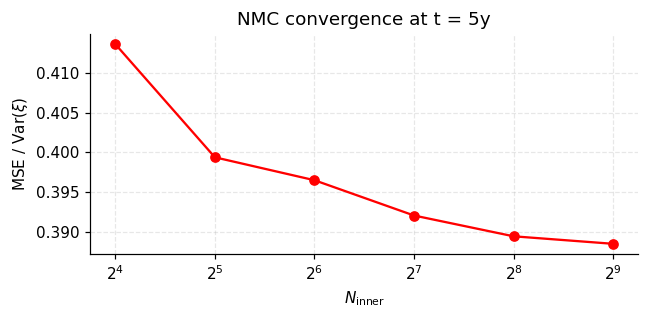

In [16]:
# plot
fig, ax = plt.subplots(figsize=(6, 3), dpi=110)
ax.plot(n_inner_grid, mse_norm_values, 'o-', color='red')
ax.set_xscale('log', base=2)
ax.set_xlabel(r'$N_\mathrm{inner}$')
ax.set_ylabel(r'MSE / Var($\xi$)')
ax.set_title(f'NMC convergence at t = {t_step_conv * dT:.0f}y')
ax.grid(alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The MSE decreases as with $N_\text{inner}$ increases and stabilizes around $0.39$. The flattening of the curve beyond $N_\text{inner} \approx 128$ $\approx 2^7$ supports our choice of $N_\text{inner} = 256$ for the NMC reference used in the validation.

We compute the NMC reference at four representative dates spanning the portfolio life $t \in \{1, 3, 5, 7\} y$ with $N_\text{inner} = 256$, $N_\text{outer} = 2^{13}$.

In [17]:
dates_years = dates_years = [1.0, 3.0, 5.0, 7.0] # running NMC as reference at selected dates
dates_steps = [int(t / dT) for t in dates_years]
n_inner = 256 

nmc_int = {}
for t_step, t_year in zip(dates_steps, dates_years):
    print(f"\n Nested MC at t={t_year}y (step {t_step})")
    t0 = time.time()
    cva, _, _ = simulate_nested_cva(
        t_i_idx=t_step, n_inner=n_inner, indicator=False,
        X=X_oos, default_step=default_step_oos, irs=irs,
        diff_params=diff_params, rho=rho,
        dt=dt, num_substeps=num_substeps, num_steps_total=num_steps_total,
        num_outer_paths=num_outer_paths_oos, fixing_window_size=fixing_window_size,
        dT=dT, seed=123,
    )
    nmc_int[t_step] = cva
    print(f"  intensity: {time.time()-t0:.1f}s | mean={cva.mean():.2f}")


 Nested MC at t=1.0y (step 10)
  intensity: 174.7s | mean=5505.74

 Nested MC at t=3.0y (step 30)
  intensity: 93.8s | mean=4346.51

 Nested MC at t=5.0y (step 50)
  intensity: 43.5s | mean=2377.11

 Nested MC at t=7.0y (step 70)
  intensity: 14.5s | mean=872.64


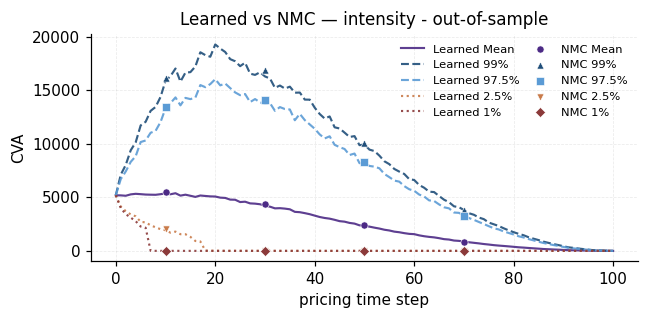

In [18]:
plot_cva_profile(cva_learned_oos_int, nmc_int, dates_steps, figsize=(6, 3), title='Learned vs NMC — intensity - out-of-sample')

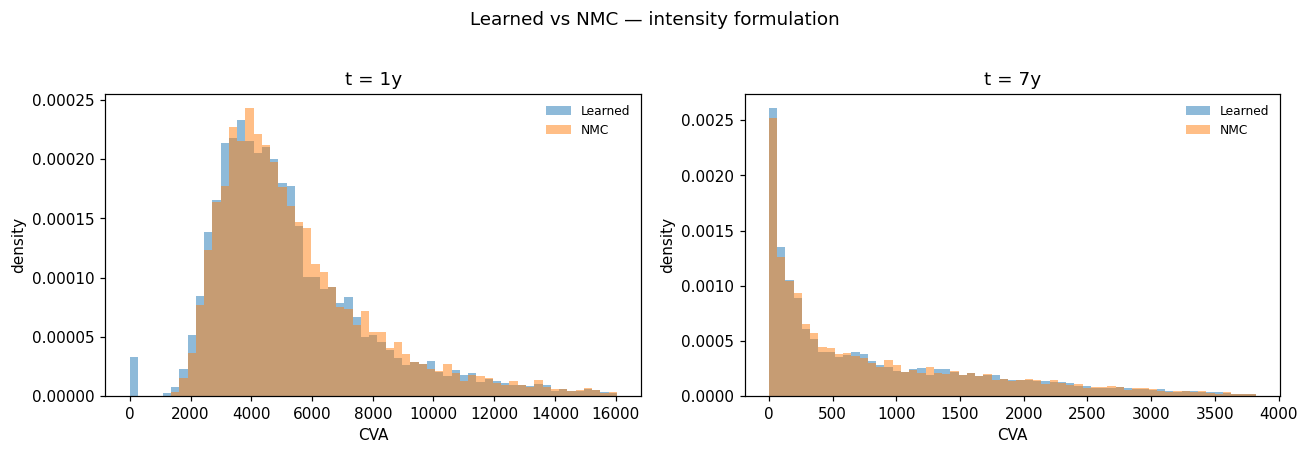

In [19]:
nmc_int_small = {10: nmc_int[10], 70: nmc_int[70]}  # restrict to t=1y and t=7y for density and QQ-plots
plot_cva_density(cva_learned_oos_int, nmc_int_small, [10, 70], [1, 7],figsize_per=(6,4), formulation='intensity')

At $t=1y$ and $t=7y$, the learned density tracks the Nested Monte Carlo estimate well including the zero mass corresponding to already-defaulted paths. 
The right tail matches well at $t=1y$, and the two distributions remain consistent at $t=7y$ where the CVA concentrates vanishes close to maturity.

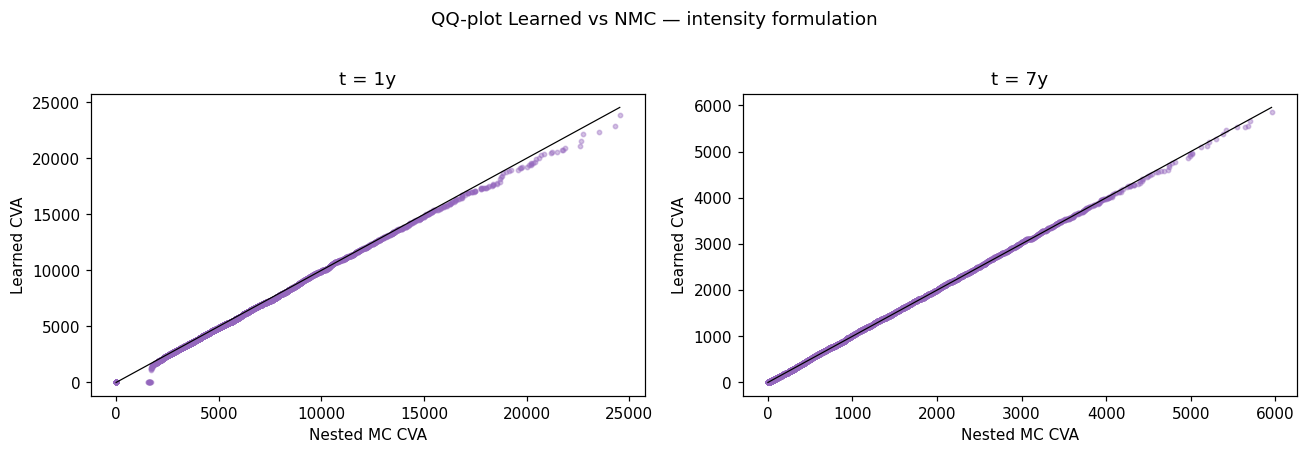

In [20]:
plot_cva_qq(cva_learned_oos_int, nmc_int_small, [10, 70], [1, 7],figsize_per=(6,4),formulation='intensity')

QQ-plots show good alignment along both dates and cofnirm that the learned and NMC distributions match across the full quantile range.

#### IV. Time budget

We compare the total computation time required to obtain the CVA estimates on the full pricing grid for both approaches, with $N_\text{outer} = 2^{13}$.

In [ ]:
#N_inner = 256
#all_dates_steps = list(range(num_steps_total + 1))  # 101 dates
#total_time_nmc = 0.0

#print(f"running NMC at {len(all_dates_steps)} dates with N_inner = {n_inner}...")
#t_global = time.time()

#for t_step in all_dates_steps:
#    t0 = time.time()
#    _, _, _ = simulate_nested_cva(
#        t_i_idx=t_step, n_inner=n_inner, indicator=False,
#        X=X_oos, default_step=default_step_oos, irs=irs,
#        diff_params=diff_params, rho=rho,
#        dt=dt, num_substeps=num_substeps, num_steps_total=num_steps_total,
#        num_outer_paths=num_outer_paths_oos, fixing_window_size=fixing_window_size,
#        dT=dT, seed=123,
#    )
#    total_time_nmc += time.time() - t0
#
#print(f"NMC total time over all dates: {total_time_nmc:.1f}s ({total_time_nmc/60:.1f} min)")

running NMC at 101 dates with N_inner = 256...


Under GPU: NVIDIA A100-PCIE-40GB, the NMC for the full pricing grid runs for more than 75 min.

In [8]:
t0 = time.time()
learner_int = LearnedCVA(**nn_cva_kwargs)
learner_int.fit(features_by_t, labels_int, formulation='intensity')
training_time_nn = time.time() - t0
print(f"NN training time: {training_time_nn:.1f}s")

Run backward NN training (CVA, intensity): 100%|██████████| 101/101 [06:16<00:00,  3.73s/it, mode=const, t=0]

NN training time: 377.4s


| Method | Computation time |
|---|---|
| NMC ($N_\text{outer} = = 2^{13}, N_\text{inner} = 256$) | > 75 min |
| Learned NN (training, all dates, $N_\text{outer} = 2^{13}$) | 377 s (≈ 6 min) |

**Speedup: ~12×** in favor of the learned approach.
Under GPU: NVIDIA A100-PCIE-40GB. The learned approach usually trains in 4-5 min but may run slower on shared infrastructure..

## References

<a id="achs"></a>
**[1]** C. Albanese, S. Crépey, R. Hoskinson, B. Saadeddine.
*XVA Analysis From the Balance Sheet.* Quantitative Finance, 21(1), 99–123, 2021.

<a id="acs"></a>
**[2]** L. A. Abbas-Turki, S. Crépey, B. Saadeddine.
*Pathwise CVA Regressions With Oversimulated Defaults.* Mathematical Finance, 2022.

<a id="acd"></a>
**[3]** L. A. Abbas-Turki, S. Crépey, B. Diallo.
*XVA Principles, Nested Monte Carlo Strategies, and GPU Optimizations.* International Journal of Theoretical and Applied Finance, 21(6), 1850030, 2018.

<a id="course"></a>
**[4]** J.F. Chassagneux.  
*Numerical Methods in Financial Engineering.* Course notes, 2026.

<a id="giles"></a>
**[5]** M. Giles.
*Advanced Monte Carlo Methods: American Options.* Lecture notes, Oxford University Mathematical Institute.

<a id="atg"></a>
**[6]** L. A. Abbas-Turki, S. Graillat.
*Resolution of a large number of small random symmetric linear systems in single precision arithmetic on GPUs.* Journal of Supercomputing, 73(4), 1360–1386, 2017.

<a id="ls"></a>
**[7]** F. A. Longstaff, E. S. Schwartz.
*Valuing American Options by Simulation: A Simple Least-Squares Approach.* Anderson Graduate School of Management, Finance, UCLA, 2001.

<a id="aaad"></a>
**[8]** B. Saadeddine. *NeuralXVA: simulation and neural-net learning of path-wise XVAs.* GitHub repository, 2020.

<a id="gpw"></a>
**[9]** M. Germain, H. Pham, X. Warin.
 *Approximation error analysis of some deep backward schemes for nonlinear PDEs.* SIAM Journal on Scientific Computing, 43(5), 2021.

<a id="acss"></a>
**[10]** L. Abbas-Turki, S. Crépey, B. Saadeddine, W. Sabbagh.
 *Pathwise XVAs: The Direct Scheme.* Preprint, 31 October 2022.

<a id="fg"></a>
**[11]** R. Ferguson, A. Green. 
*Deeply Learning Derivatives.* Preprint, version 2.1, 14 October 2018. arXiv:1809.02233.

<a id="markall"></a>
**[12]** G. Markall.
*Numba for CUDA Programmers.* NVIDIA, course materials (5 sessions), 2021.

<a id="he"></a>
**[13]** K. He, X. Zhang, S. Ren, J. Sun.
*Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification.* Proceedings of the IEEE International Conference on Computer Vision (ICCV), 2015. arXiv:1502.01852.